# Regressão com scikit-learn

Neste notebook, exploraremos técnicas fundamentais de regressão usando **scikit-learn**. Abordaremos:

1. **Regressão Linear Simples**
2. **Regressão Múltipla** com um dataset fictício
3. **Avaliação de Modelos de Regressão** com métricas como MSE, RMSE e R²
4. **Aplicação Prática** com o dataset Boston ou um dataset alternativo

# Importando bibliotecas

In [24]:
%pip install --upgrade matplotlib seaborn


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

Note: you may need to restart the kernel to use updated packages.


# Configurando o estilo dos gráficos

In [25]:
sns.set(style="darkgrid")

# 1. Regressão Linear Simples

## Criando um dataset fictício

In [26]:
np.random.seed(42)
x = 2 * np.random.rand(100, 1)
y = 4 + 3 * x + np.random.randn(100, 1)


# Dividindo os dados em treino e teste

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Treinando o modelo

In [28]:
modelo_simples = LinearRegression()
modelo_simples.fit(x_train, y_train)

LinearRegression()

# Fazendo previsões

In [29]:
y_pred = modelo_simples.predict(x_test)

## Visualizando o resultado

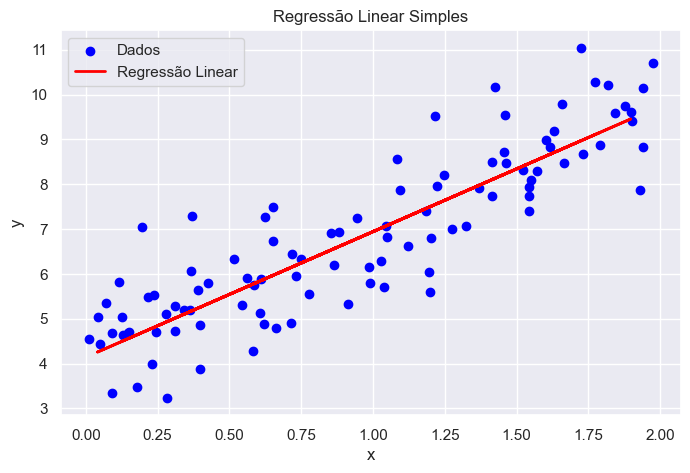

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="blue", label="Dados")
plt.plot(x_test, y_pred, color="red", linewidth=2, label="Regressão Linear")
plt.title("Regressão Linear Simples")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Avaliando o modelo

In [31]:
print("Intercepto:", modelo_simples.intercept_)
print("Coeficiente:", modelo_simples.coef_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

Intercepto: [4.14291332]
Coeficiente: [[2.79932366]]
MSE: 0.6536995137170021
RMSE: 0.8085168605026132
R²: 0.8072059636181392


# 2. Regressão Múltipla com dataset fictício

## Criando um dataset fictício

In [32]:
np.random.seed(42)
x = np.random.rand(100, 2)  # Duas variáveis independentes
y = 5 + 2 * x[:, 0] + 3 * x[:, 1] + np.random.randn(100)

# Convertendo para DataFrame

In [33]:
dados = pd.DataFrame(x, columns=["Var1", "Var2"])
dados["Target"] = y

# Dividindo os dados em treino e teste

In [34]:
x_train, x_test, y_train, y_test = train_test_split(dados[["Var1", "Var2"]], dados["Target"], test_size=0.2, random_state=42)


## Treinando o modelo

In [35]:
modelo_multiplo = LinearRegression()
modelo_multiplo.fit(x_train, y_train)

LinearRegression()

# Fazendo previsões

In [36]:
y_pred = modelo_multiplo.predict(x_test)


# Avaliando o modelo

In [37]:
print("Intercepto:", modelo_multiplo.intercept_)
print("Coeficientes:", modelo_multiplo.coef_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

Intercepto: 4.71667149938969
Coeficientes: [2.25451356 3.4741599 ]
MSE: 0.7144483936493806
RMSE: 0.845250491658763
R²: 0.5102276293518453


# 3. Avaliação de Modelos de Regressão

## Funções para cálculo de métricas

In [38]:
def avaliar_modelo(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2


In [39]:
mse, rmse, r2 = avaliar_modelo(y_test, y_pred)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 0.7144483936493806
RMSE: 0.845250491658763
R²: 0.5102276293518453


# 4. Aplicação Prática com Dataset California Housing

## Carregando o dataset

In [40]:
california = fetch_california_housing(as_frame=True)
data = california.frame

# Selecionando features e target

In [41]:
x = data.drop(columns=["MedHouseVal"])
y = data["MedHouseVal"]


# Dividindo em treino e teste

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Treinando o modelo

In [43]:
modelo_california = LinearRegression()
modelo_california.fit(x_train, y_train)

LinearRegression()

# Fazendo previsões

In [44]:
y_pred = modelo_california.predict(x_test)

# Avaliando o modelo

In [45]:
mse, rmse, r2 = avaliar_modelo(y_test, y_pred)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 0.555891598695244
RMSE: 0.7455813830127761
R²: 0.5757877060324511


## Visualizando as previsões

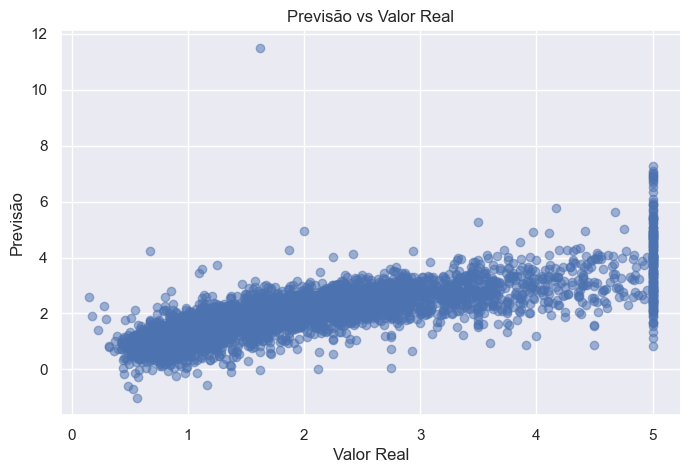

In [46]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title("Previsão vs Valor Real")
plt.xlabel("Valor Real")
plt.ylabel("Previsão")
plt.show()